# Tutorial 3: Relating spikes to another signal with `.alt()`

Often you want to know what else was happening around each spike: the stimulus, the local field potential, behaviour. `.alt()` cuts a window of a second signal around a reference point of every spike (for example 200 ms before the inflection), runs your own function on each window, and adds the results as new columns in the feature table. The second signal can have its own sampling rate.

Here we use the pink noise sweeps and ask: does the shape of a spike reflect the current the neuron received just before it? This mirrors, in a simplified form, the analysis behind Finding 2 of Martin-Burgos et al. (2026); see its [walkthrough notebook](../../Action%20potential%20waveforms%20are%20state-dependent%20paper/2_electrical_stimulation_causally_influences_spike_waveform.ipynb).

`spikewise` was developed for, and is described in:

> Martin-Burgos, B., Juavinett, A., Riviere, P., Hammonds, R., & Voytek, B. (2026). *Action potential waveforms are state-dependent*. bioRxiv. https://www.biorxiv.org/content/10.64898/2026.09.15.751814v1

Please cite it if you use `spikewise`.

The example data (`data/example_recordings.npz`, 2.6 MB) are short excerpts of two open datasets, so the tutorial runs without downloading anything:
- **pvc-6** (Berg, 2014; CRCNS): whole-cell patch clamp recordings from an SST+ interneuron in mouse visual cortex, driven with constant, ramp and pink noise current. 14 sweeps, voltage at 50 kHz and injected current at 10 kHz.
- **spe-1** (Marques-Smith et al., 2018; CRCNS): 5 s of a juxtacellular recording from a pyramidal neuron in rat cortex, at about 50 kHz.

`data/build_tutorial_data.py` shows how the excerpts were made.

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from spikewise.patch.fit import SpikeGroup

In [2]:
d = np.load('data/example_recordings.npz')
fs, current_fs = int(d['voltage_fs']), int(d['current_fs'])

def voltage(key):   # membrane voltage (mV) of one sweep
    return d[f'{key}_voltage'] / d['voltage_scale']

def current(key):   # injected current (pA) of one sweep
    return d[f'{key}_current'] / d['current_scale']

sweeps = pd.DataFrame({'key': d['sweep_keys'], 'sweep': d['sweep_numbers'], 'stim_type': d['stim_types']})
pink = list(sweeps.loc[sweeps['stim_type'] == 'pink', 'key'])
print(f'{len(pink)} pink noise sweeps')

10 pink noise sweeps


## 1. Fit the spikes

In [3]:
sg = SpikeGroup(thresh_amp=-10, window_length=(5., 5.), smooth_frac=.008, pre_inflection_ms=0.5)
sg.fit(pink, fs, reader=voltage)
print(f'{sg.df_features.shape[0]} spikes')

137 spikes


## 2. Describe the current before each spike

Write a function that takes one window of the second signal and its sampling rate, and returns one number per feature. Here: the mean and standard deviation of the injected current.

In [4]:
def current_stats(window, fs):
    return np.mean(window), np.std(window)

Then call `.alt()` with the second signal (again through a `reader`), its sampling rate, your function, names for its outputs, the reference point, and the window around it in ms. `window_length=(200., 0.)` means 200 ms before the inflection and nothing after, so the window ends just as the spike takes off.

In [5]:
sg.alt(pink, current_fs, current_stats, param_keys=['current_mean', 'current_sd'],
       ref='inflection', window_length=(200., 0.), reader=current)
sg.df_features[['peak_amp', 'exp_lambda', 'current_mean', 'current_sd']].round(2).head()

,peak_amp,exp_lambda,current_mean,current_sd
0,8.83,1.84,6.39,8.30
1,7.72,1.69,16.14,4.73
2,7.74,1.69,15.46,3.49
3,7.84,1.66,15.41,3.48
4,8.59,1.84,8.63,5.97


The windows themselves are stored in `sg.alt_windows`, one row per spike:

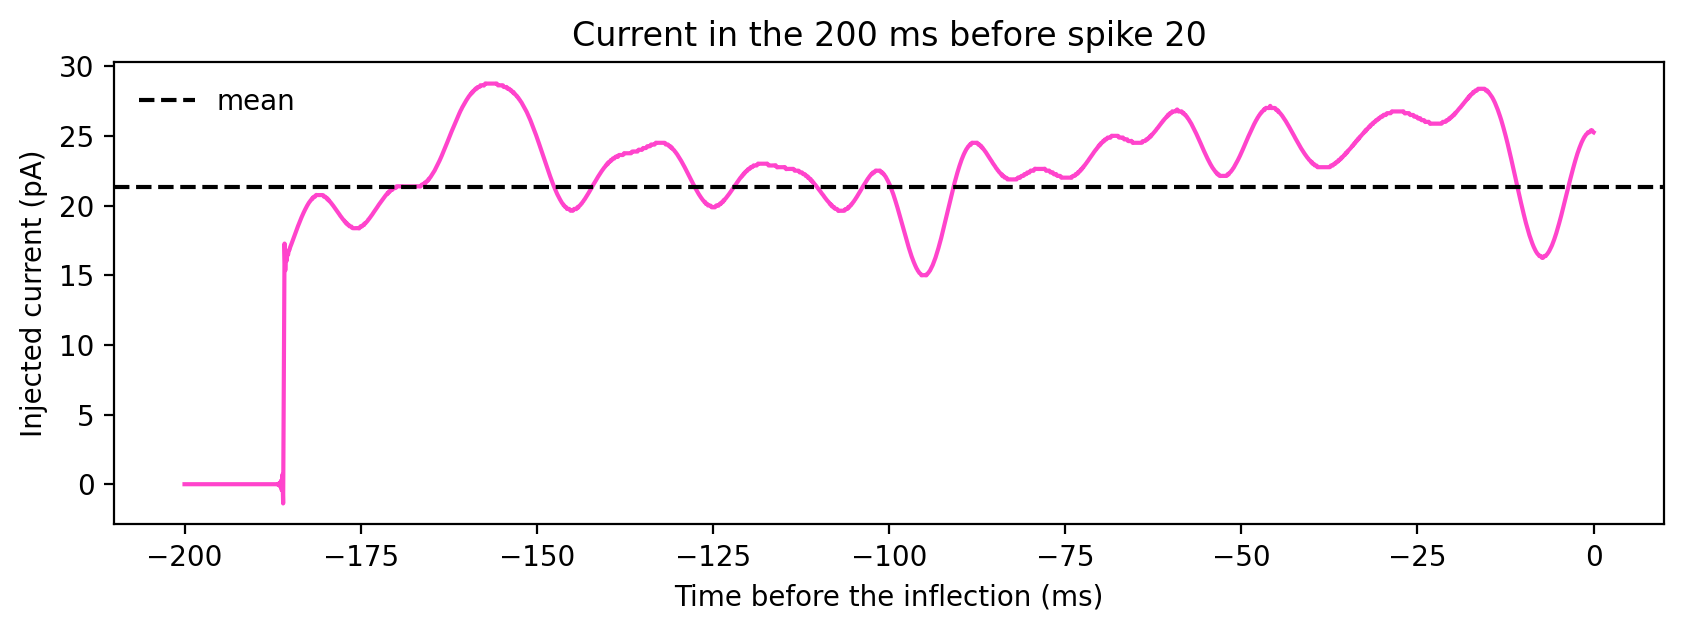

In [6]:
win_t = np.linspace(-200, 0, sg.alt_windows.shape[1])
spike = 20
plt.figure(figsize=(10, 3))
plt.plot(win_t, sg.alt_windows[spike], color='#FF44CC')
plt.axhline(sg.df_features['current_mean'].iloc[spike], color='k', ls='--', label='mean')
plt.xlabel('Time before the inflection (ms)')
plt.ylabel('Injected current (pA)')
plt.title(f'Current in the 200 ms before spike {spike}')
plt.legend(frameon=False)
plt.show()

## 3. Does spike shape track the input?

A first look: each waveform feature against the mean current before the spike.

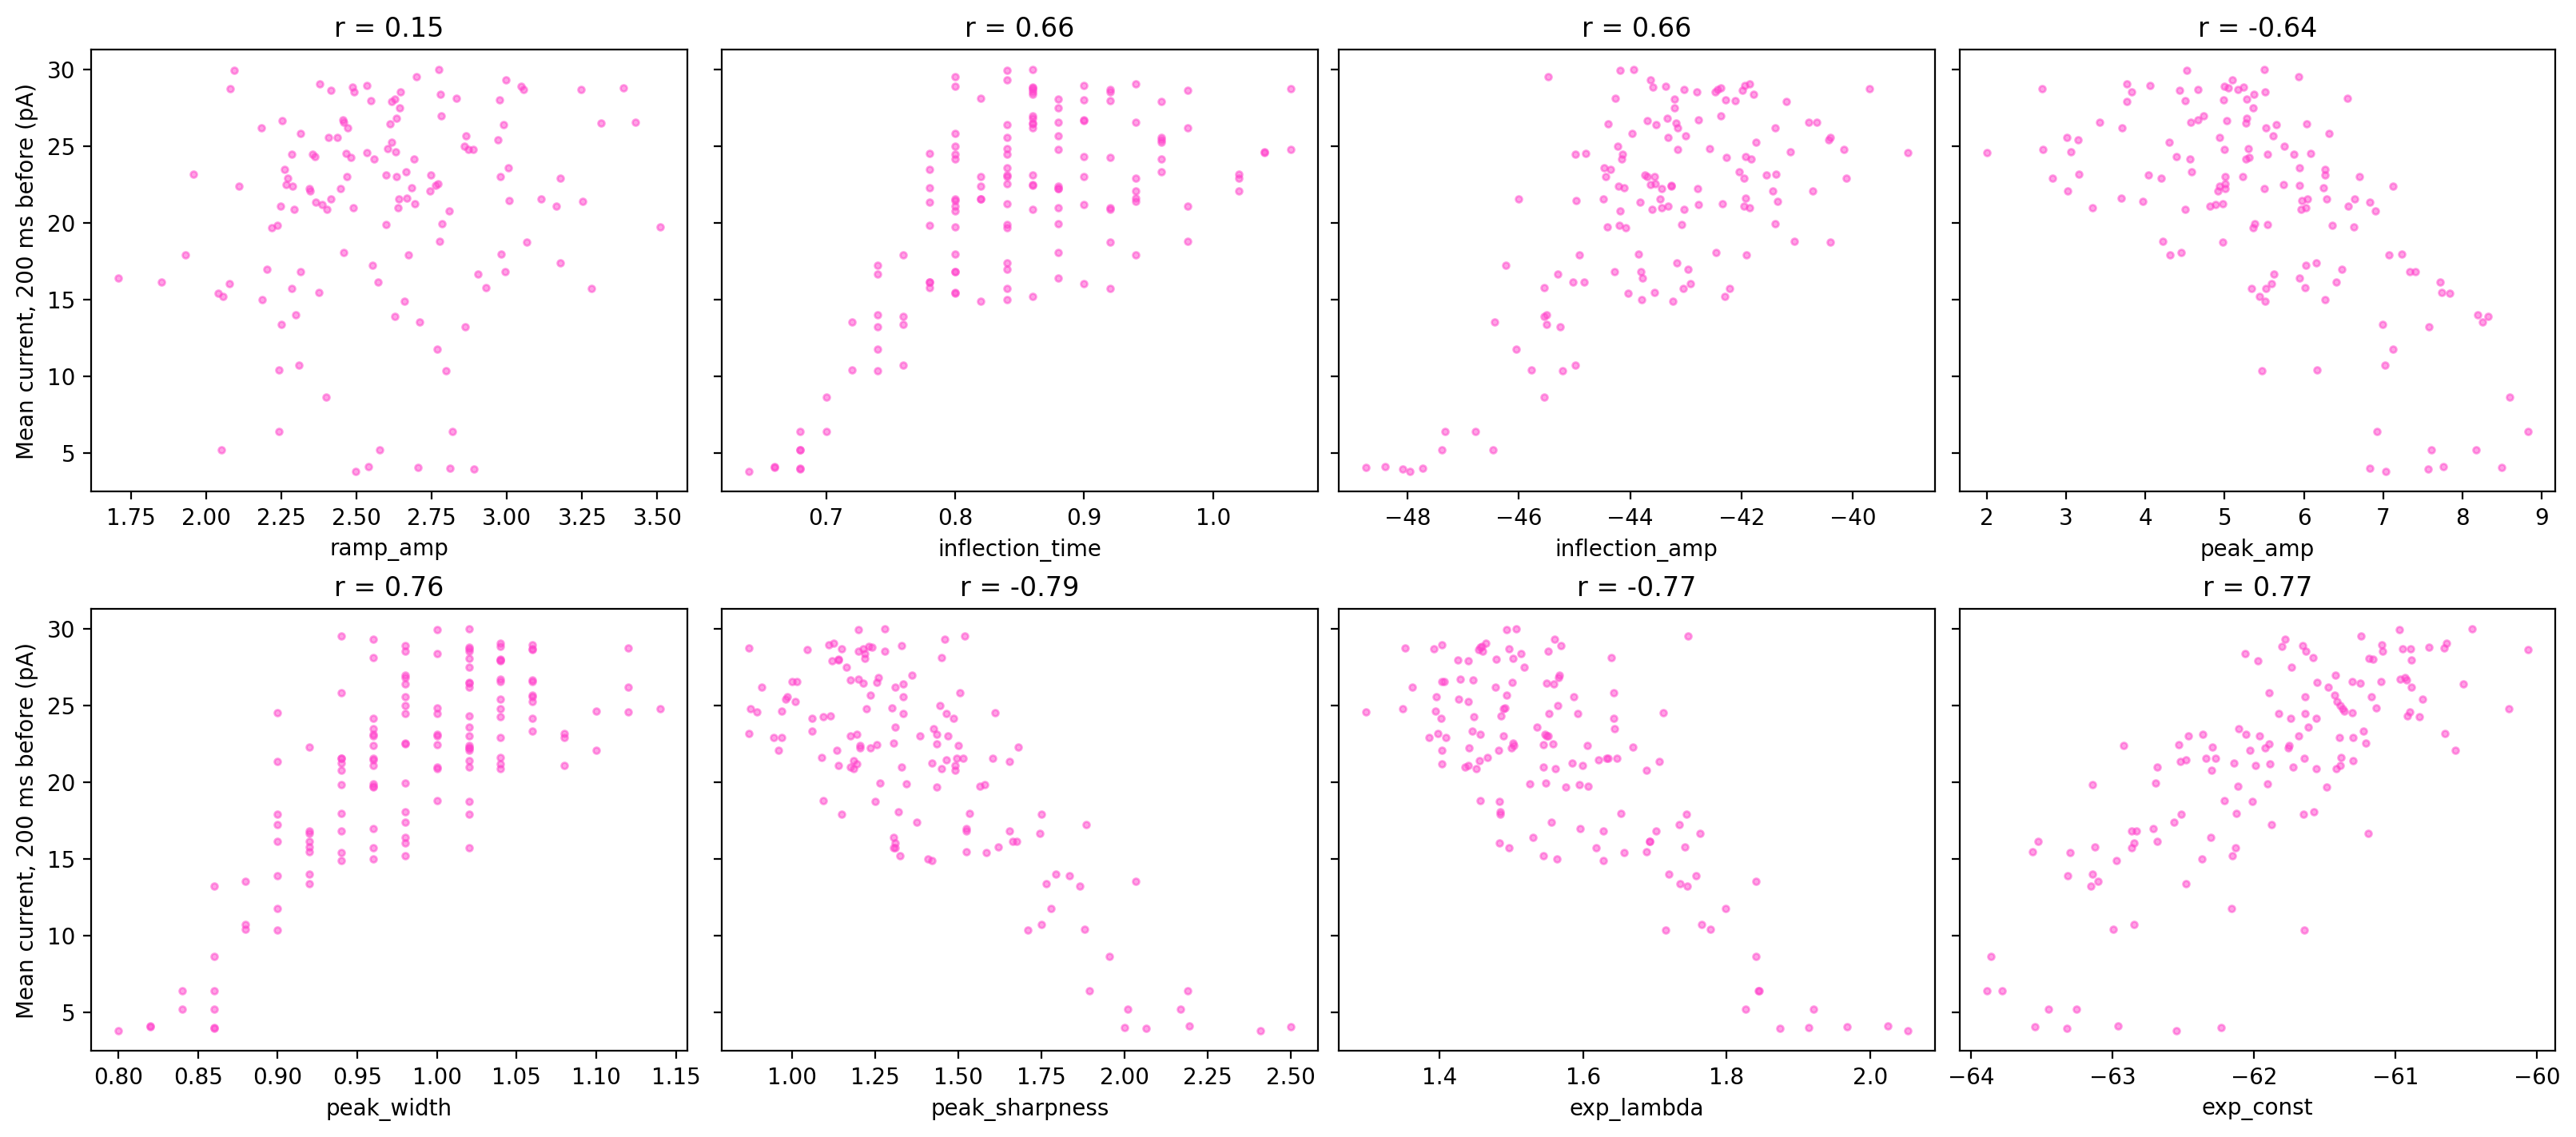

In [7]:
features = ['ramp_amp', 'inflection_time', 'inflection_amp', 'peak_amp',
            'peak_width', 'peak_sharpness', 'exp_lambda', 'exp_const']
df = sg.df_features.dropna(subset=features + ['current_mean'])

fig, axes = plt.subplots(2, 4, figsize=(16, 7), constrained_layout=True, sharey=True)
for ax, feat in zip(axes.flat, features):
    ax.scatter(df[feat], df['current_mean'], s=8, alpha=0.5, color='#FF44CC')
    ax.set_xlabel(feat)
    ax.set_title(f"r = {df[feat].corr(df['current_mean']):.2f}")
for ax in axes[:, 0]:
    ax.set_ylabel('Mean current, 200 ms before (pA)')
plt.show()

Then a model using all waveform features together: a cross-validated ridge regression, compared with the same model fit to shuffled targets, which should score near zero. Only waveform features go into the model, not the sweep number: each sweep is a different pink noise, so the sweep number alone would already tell the model a lot about the input.

In [8]:
X = df[features].values
model = make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-3, 3, 50)))
cv = KFold(n_splits=5, shuffle=True, random_state=0)
rng = np.random.default_rng(0)

for target in ['current_mean', 'current_sd']:
    y = df[target].values
    r2 = cross_val_score(model, X, y, cv=cv, scoring='r2').mean()
    r2_shuffled = np.mean([cross_val_score(model, X, rng.permutation(y), cv=cv, scoring='r2').mean()
                           for _ in range(20)])
    print(f'{target:<13} cross-validated R² = {r2:.2f}   (shuffled: {r2_shuffled:.2f})')

current_mean  cross-validated R² = 0.72   (shuffled: -0.05)
current_sd    cross-validated R² = 0.42   (shuffled: -0.08)


The analysis in Martin-Burgos et al. (2026) adds bootstrapped confidence intervals, permutation tests and a sweep through window lengths from 5 to 500 ms; see the [Finding 2 walkthrough notebook](../../Action%20potential%20waveforms%20are%20state-dependent%20paper/2_electrical_stimulation_causally_influences_spike_waveform.ipynb).

## Other signals

The same pattern works for any signal recorded alongside the spikes. For example, with a simultaneously recorded LFP at 2.5 kHz you could compute its mean and variability in the 500 ms around each spike peak:

```python
sg.alt(lfp_recordings, 2500, lfp_stats, param_keys=['lfp_mean', 'lfp_sd'],
       ref='peak', window_length=(250., 250.), reader=load_lfp)
```

`ref` can be any control point: `'ramp_start'`, `'inflection'`, `'rise'`, `'peak'`, `'decay'`, `'exp_start'` or `'exp_end'`.